# Water Height Time Series - EDA & Cleaning

## 📖 Summary

This notebook explores the **66 water height stations** (2016-2024) to understand data distributions, identify outliers and anomalies, and apply informed cleaning decisions. The goal is to prepare high-quality time series data for feature engineering.

**Input:** `timeseries/water_height/*.parquet` (66 raw files)

**Output:** `timeseries/cleaned/water_height/*.parquet` (66 cleaned files) + cleaning report

## 🎯 Objectives

1. **Understand data distributions** - What's the range? Are there patterns?
2. **Identify outliers** - Error codes, impossible values, suspicious spikes
3. **Define cleaning rules** - Based on domain knowledge + statistical analysis
4. **Apply cleaning** - Remove bad data with full documentation
5. **Validate results** - Confirm cleaning improved data quality

## 📋 Analysis Flow

**Part 1: Exploratory Data Analysis**
1. Load all station data
2. Overall distribution analysis
3. Station-by-station summaries
4. Temporal patterns (seasonal, annual)
5. Outlier identification

**Part 2: Define Cleaning Rules**
6. Domain knowledge constraints
7. Statistical outlier thresholds
8. Document rationale

**Part 3: Apply Cleaning**
9. Execute cleaning with logging
10. Track removed values

**Part 4: Validation**
11. Before/after comparisons
12. Generate cleaning report
13. Save cleaned data

---

## 1. Setup & Configuration

In [1]:
# Imports
import sys
sys.path.insert(0, "..")
sys.path.append("../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10

print("✅ Imports successful!")

✅ Imports successful!


/Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Import paths
import src.paths as PATHS

In [3]:
# Configuration
RAW_DIR = PATHS.DATA_DIR / "water_stations_timeseries" / "water_height"
OUTPUT_DIR = PATHS.DATA_DIR / "water_stations_timeseries" / "cleaned" / "water_height"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_DIR = PATHS.DATA_DIR / "water_stations_timeseries" / "cleaning_reports"
REPORT_DIR.mkdir(exist_ok=True)

print(f"📂 Raw data: {RAW_DIR}")
print(f"📁 Output: {OUTPUT_DIR}")
print(f"📊 Reports: {REPORT_DIR}")

📂 Raw data: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/water_height
📁 Output: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaned/water_height
📊 Reports: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaning_reports


---
# Part 1: Exploratory Data Analysis
---

## 2. Load All Station Data

In [4]:
print("📥 Loading all water height station data...\n")

# Get all parquet files
parquet_files = sorted(list(RAW_DIR.glob('*.parquet')))
print(f"Found {len(parquet_files)} station files\n")

# Load all data
all_data = []
station_info = []

for file in tqdm(parquet_files, desc="Loading stations"):
    df = pd.read_parquet(file)
    station_code = df['station_code'].iloc[0]
    
    all_data.append(df)
    
    station_info.append({
        'station_code': station_code,
        'measurements': len(df),
        'min_value': df['water_level_cm'].min(),
        'max_value': df['water_level_cm'].max(),
        'mean_value': df['water_level_cm'].mean(),
        'std_value': df['water_level_cm'].std(),
        'start_date': df['timestamp'].min(),
        'end_date': df['timestamp'].max(),
        'years': df['year'].nunique()
    })

# Combine all data
combined_df = pd.concat(all_data, ignore_index=True)
station_info_df = pd.DataFrame(station_info)

print(f"\n✅ Loaded {len(station_info_df)} stations")
print(f"📊 Total measurements: {len(combined_df):,}")
print(f"📅 Date range: {combined_df['timestamp'].min()} to {combined_df['timestamp'].max()}")

📥 Loading all water height station data...

Found 66 station files



Loading stations: 100%|██████████| 66/66 [00:01<00:00, 55.61it/s]



✅ Loaded 66 stations
📊 Total measurements: 27,828,328
📅 Date range: 2016-01-01 00:00:00+01:00 to 2024-12-31 23:50:00+01:00


## 3. Overall Distribution Analysis

In [5]:
print("="*80)
print("OVERALL WATER LEVEL DISTRIBUTION")
print("="*80)

print(f"\n📊 Summary statistics (cm above NAP):\n")
print(combined_df['water_level_cm'].describe())

print(f"\n📈 Percentiles:\n")
percentiles = [0.1, 1, 5, 25, 50, 75, 95, 99, 99.9]
for p in percentiles:
    value = combined_df['water_level_cm'].quantile(p/100)
    print(f"   {p:5.1f}%: {value:10.2f} cm")

OVERALL WATER LEVEL DISTRIBUTION

📊 Summary statistics (cm above NAP):

count    2.782833e+07
mean     9.325657e+02
std      1.165279e+03
min     -3.300000e+04
25%      1.470000e+02
50%      6.690000e+02
75%      1.146000e+03
max      1.675600e+04
Name: water_level_cm, dtype: float64

📈 Percentiles:

     0.1%:     -55.00 cm
     1.0%:     -38.00 cm
     5.0%:     -19.00 cm
    25.0%:     147.00 cm
    50.0%:     669.00 cm
    75.0%:    1146.00 cm
    95.0%:    3513.00 cm
    99.0%:    3899.00 cm
    99.9%:    4085.00 cm


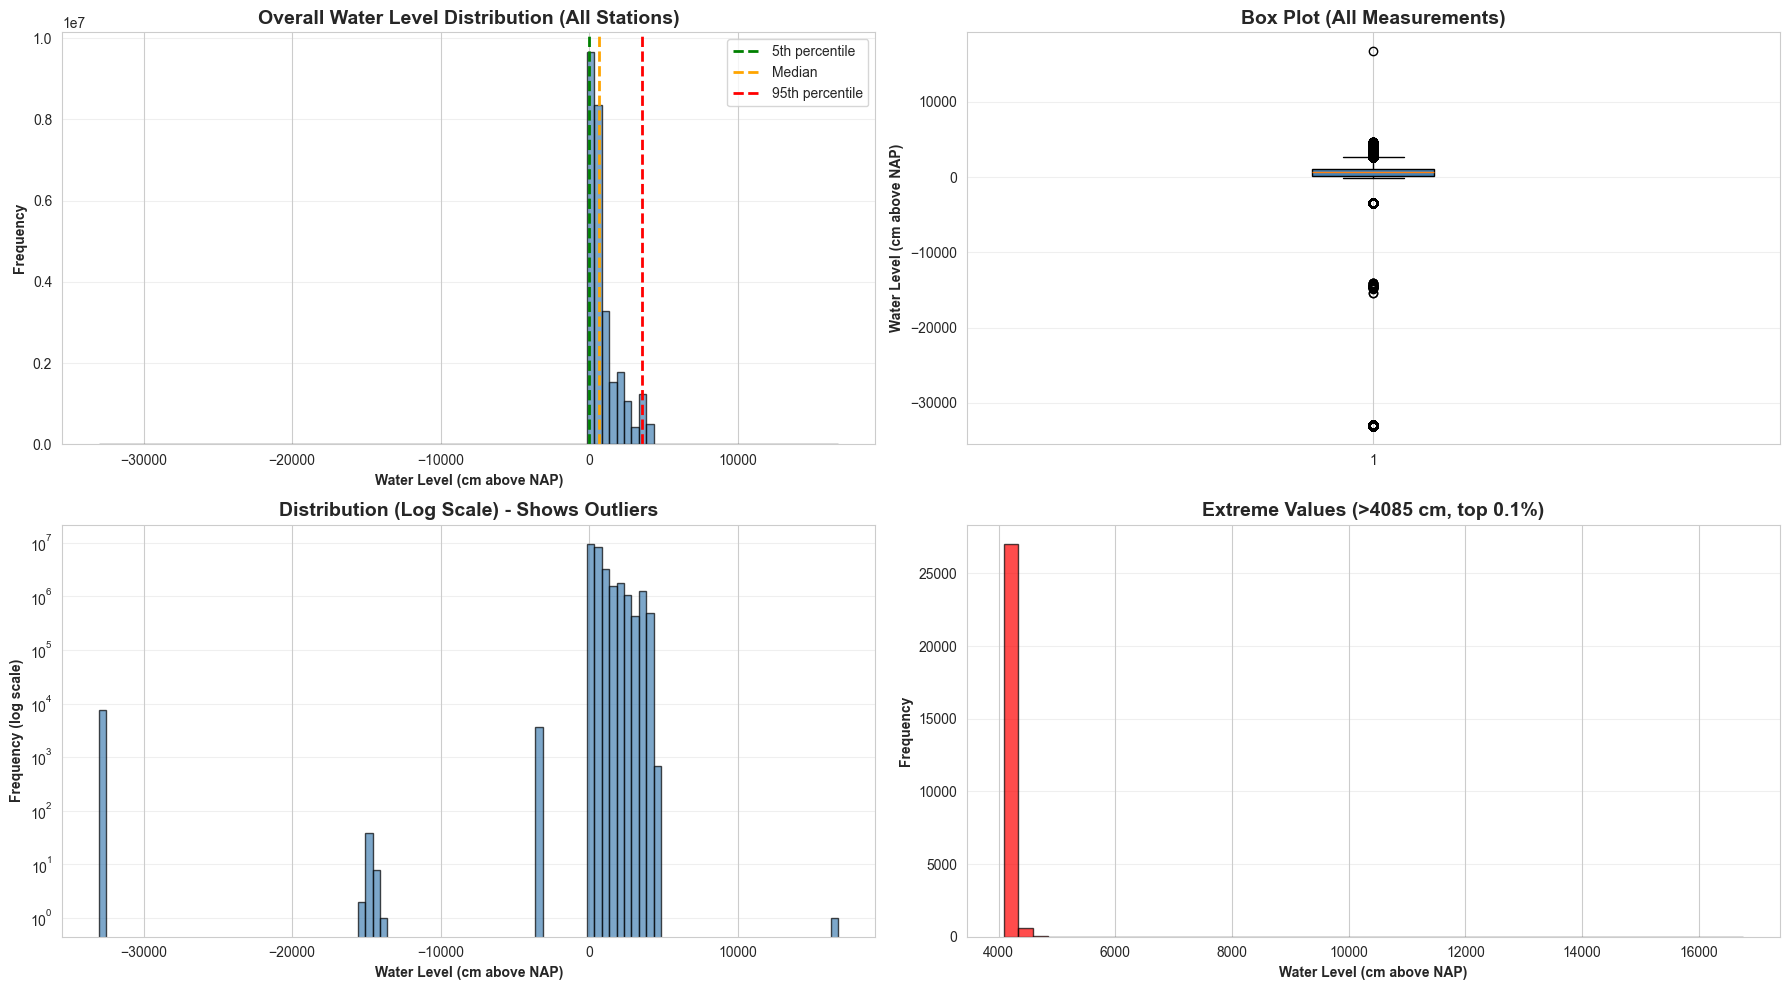


💡 Observations:
   • Distribution shape: Left-skewed
   • Extreme values (>99.9%): 27,620 measurements


In [6]:
# Visualization: Overall distribution
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Histogram
ax1 = axes[0, 0]
ax1.hist(combined_df['water_level_cm'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(combined_df['water_level_cm'].quantile(0.05), color='green', linestyle='--', linewidth=2, label='5th percentile')
ax1.axvline(combined_df['water_level_cm'].quantile(0.50), color='orange', linestyle='--', linewidth=2, label='Median')
ax1.axvline(combined_df['water_level_cm'].quantile(0.95), color='red', linestyle='--', linewidth=2, label='95th percentile')
ax1.set_xlabel('Water Level (cm above NAP)', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('Overall Water Level Distribution (All Stations)', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Box plot
ax2 = axes[0, 1]
bp = ax2.boxplot(combined_df['water_level_cm'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
ax2.set_ylabel('Water Level (cm above NAP)', fontweight='bold')
ax2.set_title('Box Plot (All Measurements)', fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Log-scale histogram (to see extremes)
ax3 = axes[1, 0]
ax3.hist(combined_df['water_level_cm'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
ax3.set_yscale('log')
ax3.set_xlabel('Water Level (cm above NAP)', fontweight='bold')
ax3.set_ylabel('Frequency (log scale)', fontweight='bold')
ax3.set_title('Distribution (Log Scale) - Shows Outliers', fontweight='bold', fontsize=14)
ax3.grid(axis='y', alpha=0.3)

# Extreme values focus
ax4 = axes[1, 1]
extreme_threshold = combined_df['water_level_cm'].quantile(0.999)
extremes = combined_df[combined_df['water_level_cm'] > extreme_threshold]
ax4.hist(extremes['water_level_cm'], bins=50, edgecolor='black', alpha=0.7, color='red')
ax4.set_xlabel('Water Level (cm above NAP)', fontweight='bold')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title(f'Extreme Values (>{extreme_threshold:.0f} cm, top 0.1%)', fontweight='bold', fontsize=14)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Observations:")
print(f"   • Distribution shape: {'Right-skewed' if combined_df['water_level_cm'].skew() > 0 else 'Left-skewed'}")
print(f"   • Extreme values (>99.9%): {len(extremes):,} measurements")

## 4. Station-by-Station Summary

In [7]:
print("="*80)
print("STATION-BY-STATION SUMMARY")
print("="*80)

# Sort by various metrics
print(f"\n📊 Top 10 stations by maximum water level:\n")
print(station_info_df.nlargest(10, 'max_value')[['station_code', 'max_value', 'mean_value']].to_string(index=False))

print(f"\n📊 Top 10 stations by variability (std):\n")
print(station_info_df.nlargest(10, 'std_value')[['station_code', 'std_value', 'mean_value']].to_string(index=False))

print(f"\n📊 Stations with potential issues (min < -1000 or max > 3000):\n")
suspicious = station_info_df[(station_info_df['min_value'] < -1000) | (station_info_df['max_value'] > 3000)]
if len(suspicious) > 0:
    print(suspicious[['station_code', 'min_value', 'max_value', 'measurements']].to_string(index=False))
else:
    print("   None found!")

STATION-BY-STATION SUMMARY

📊 Top 10 stations by maximum water level:

                     station_code  max_value  mean_value
                   negenoord.oost    16756.0 2481.331024
                          lanaken     4653.0 3725.244299
maastricht.borgharen.maas.beneden     4523.0 3884.364680
                         uikhoven     4261.0 3546.622846
                      elsloo.maas     4095.0 3422.813292
eisdenmazenhove.maesbempdergreend     3777.0 2494.845792
                   negenoord.west     3279.0 2742.992991
                          maaseik     3017.0 2201.595416
                        spaanjerd     2674.0 2118.365882
                     stevensweert     2557.0 2118.055078

📊 Top 10 stations by variability (std):

                     station_code   std_value  mean_value
eisdenmazenhove.maesbempdergreend 3875.394009 2494.845792
                   negenoord.oost 2551.449333 2481.331024
                          lanaken 1332.098054 3725.244299
                         uik

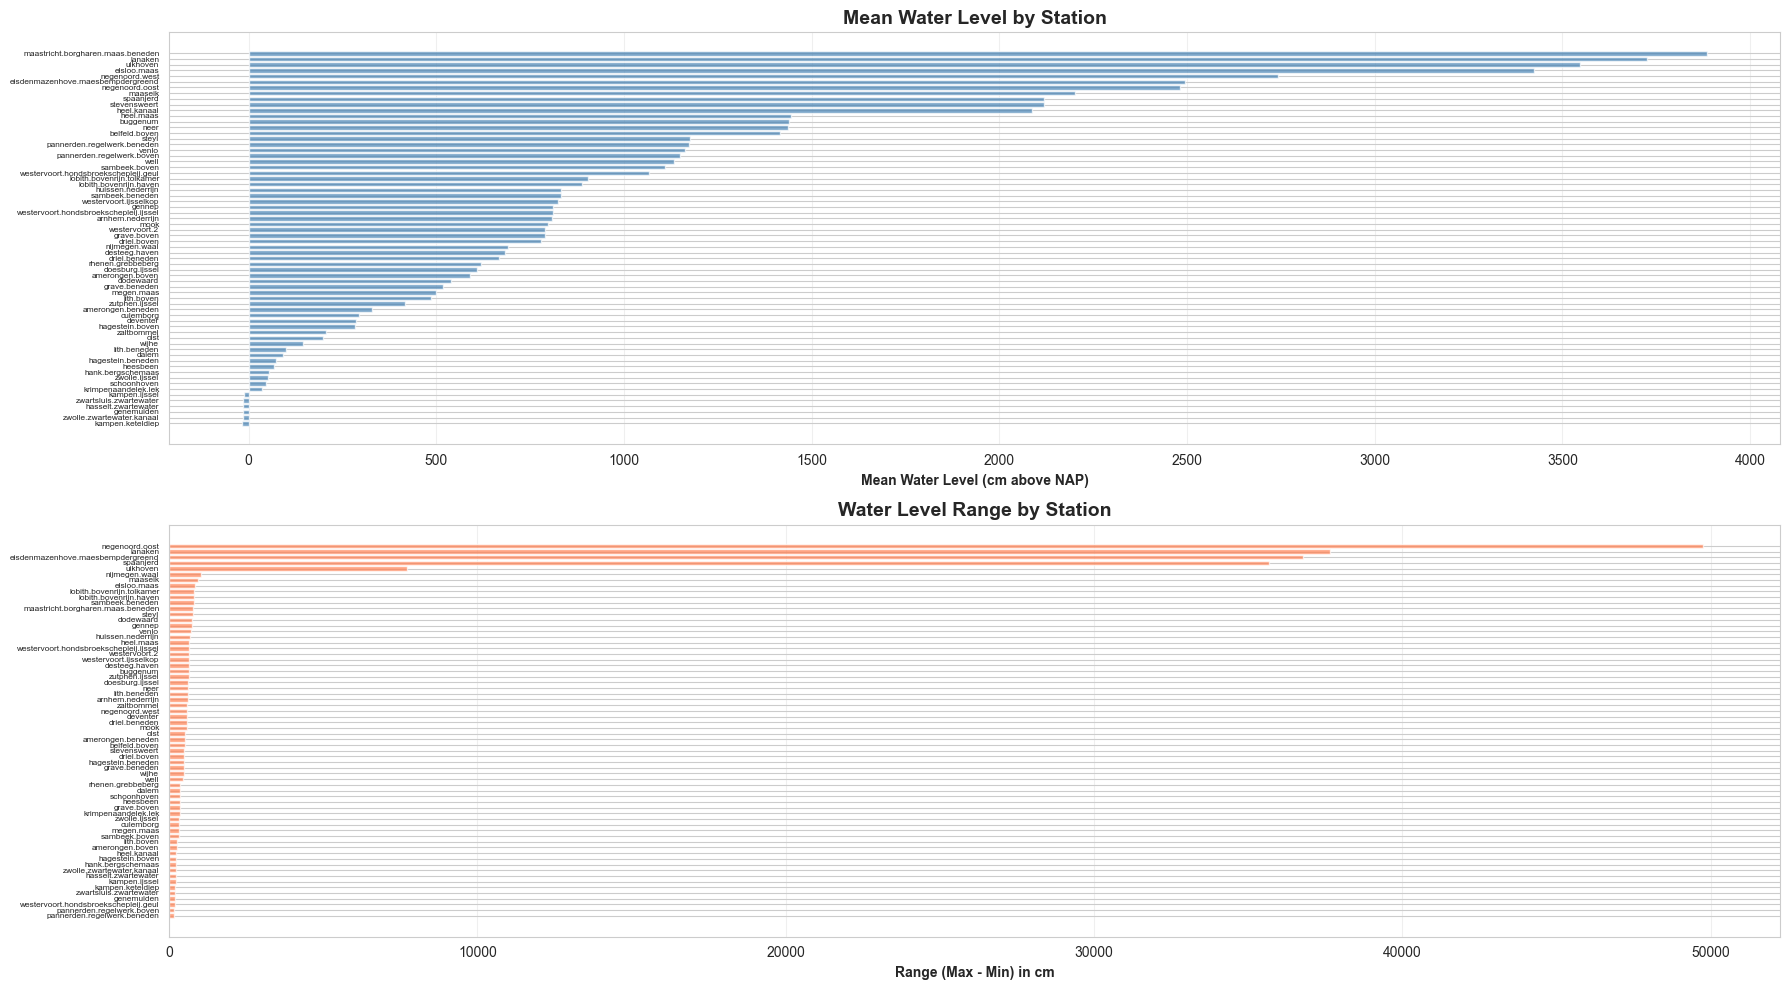

In [8]:
# Visualization: Station comparison
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Mean water level by station
ax1 = axes[0]
station_info_sorted = station_info_df.sort_values('mean_value')
ax1.barh(range(len(station_info_sorted)), station_info_sorted['mean_value'], color='steelblue', alpha=0.7)
ax1.set_yticks(range(len(station_info_sorted)))
ax1.set_yticklabels(station_info_sorted['station_code'], fontsize=6)
ax1.set_xlabel('Mean Water Level (cm above NAP)', fontweight='bold')
ax1.set_title('Mean Water Level by Station', fontweight='bold', fontsize=14)
ax1.grid(axis='x', alpha=0.3)

# Range (max - min) by station
ax2 = axes[1]
station_info_sorted['range'] = station_info_sorted['max_value'] - station_info_sorted['min_value']
station_info_sorted = station_info_sorted.sort_values('range')
ax2.barh(range(len(station_info_sorted)), station_info_sorted['range'], color='coral', alpha=0.7)
ax2.set_yticks(range(len(station_info_sorted)))
ax2.set_yticklabels(station_info_sorted['station_code'], fontsize=6)
ax2.set_xlabel('Range (Max - Min) in cm', fontweight='bold')
ax2.set_title('Water Level Range by Station', fontweight='bold', fontsize=14)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Temporal Patterns

In [9]:
# Add temporal features
combined_df['month'] = combined_df['timestamp'].dt.month
combined_df['season'] = combined_df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

print("="*80)
print("TEMPORAL PATTERNS")
print("="*80)

print(f"\n📊 Mean water level by year:\n")
yearly_mean = combined_df.groupby('year')['water_level_cm'].mean()
print(yearly_mean)

print(f"\n📊 Mean water level by season:\n")
seasonal_mean = combined_df.groupby('season')['water_level_cm'].mean().sort_values(ascending=False)
print(seasonal_mean)

TEMPORAL PATTERNS

📊 Mean water level by year:

year
2016    956.986810
2017    860.361953
2018    890.259322
2019    945.030626
2020    941.680063
2021    965.214572
2022    924.668490
2023    947.887553
2024    950.772519
Name: water_level_cm, dtype: float64

📊 Mean water level by season:

season
Winter    993.098739
Spring    955.283558
Fall      902.299480
Summer    879.848569
Name: water_level_cm, dtype: float64


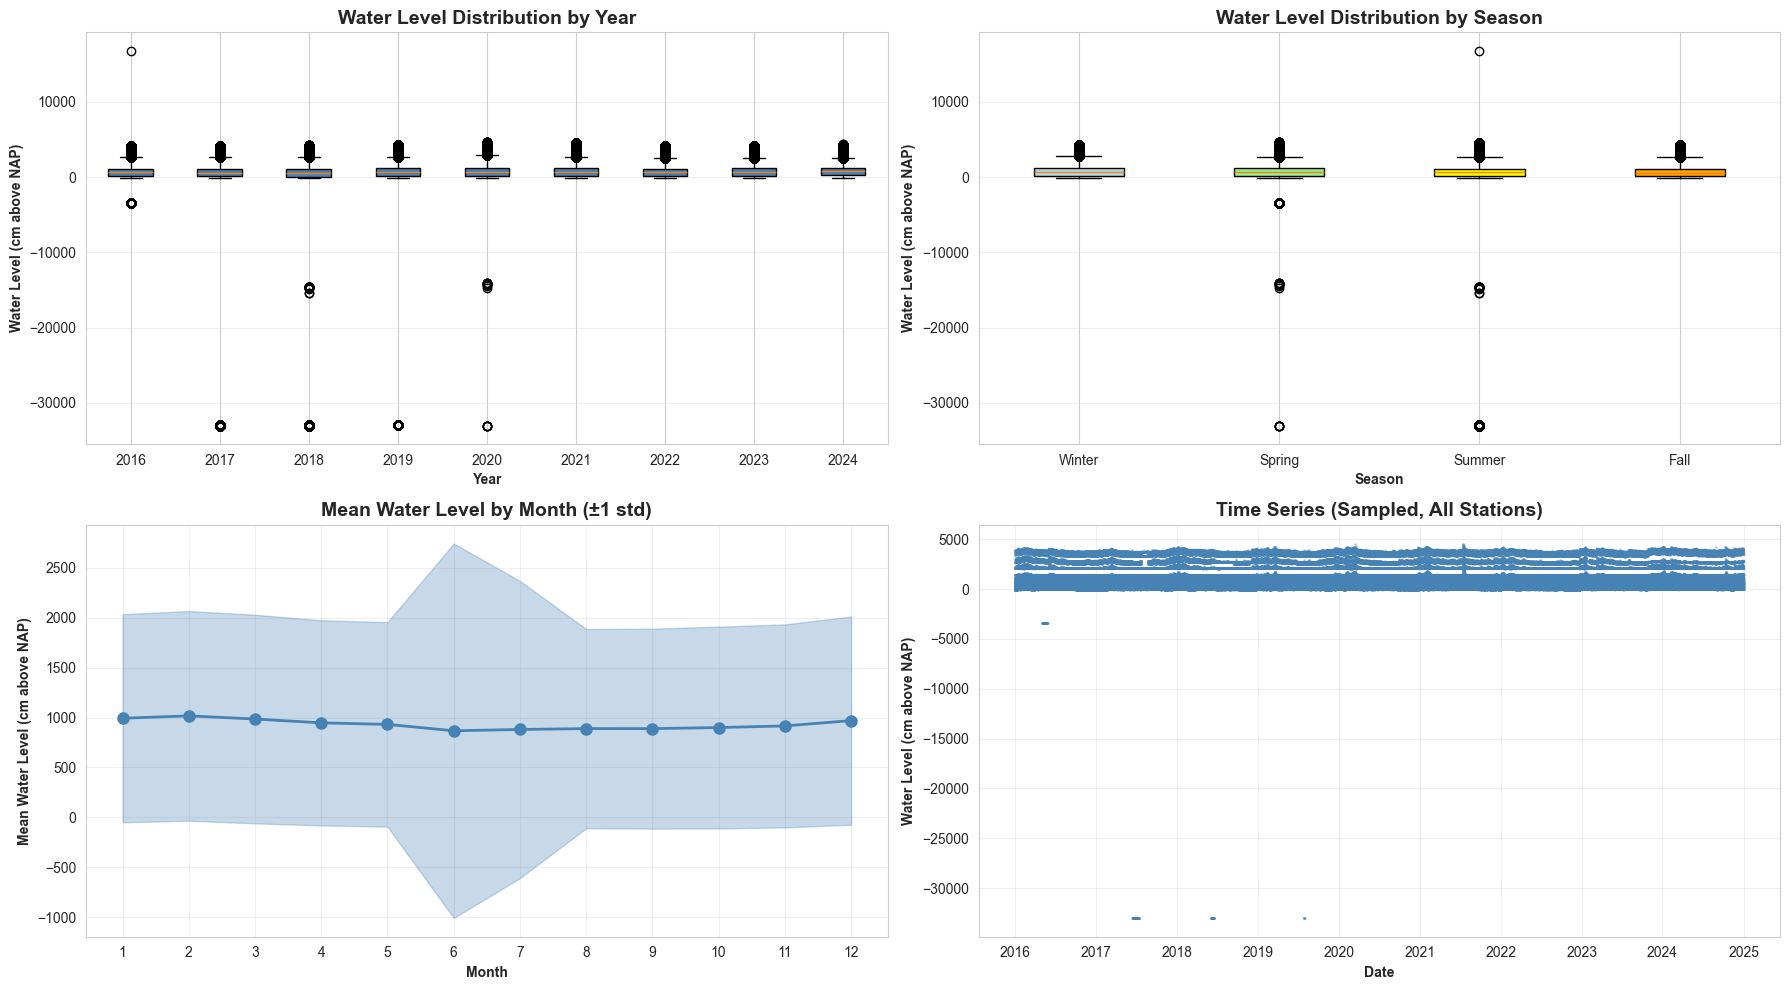

In [10]:
# Visualization: Temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Year-by-year distributions
ax1 = axes[0, 0]
years = sorted(combined_df['year'].unique())
data_by_year = [combined_df[combined_df['year'] == year]['water_level_cm'].values for year in years]
bp1 = ax1.boxplot(data_by_year, labels=years, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Water Level (cm above NAP)', fontweight='bold')
ax1.set_title('Water Level Distribution by Year', fontweight='bold', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

# Seasonal patterns
ax2 = axes[0, 1]
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
data_by_season = [combined_df[combined_df['season'] == season]['water_level_cm'].values for season in season_order]
bp2 = ax2.boxplot(data_by_season, labels=season_order, patch_artist=True)
colors = ['lightblue', 'lightgreen', 'yellow', 'orange']
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
ax2.set_xlabel('Season', fontweight='bold')
ax2.set_ylabel('Water Level (cm above NAP)', fontweight='bold')
ax2.set_title('Water Level Distribution by Season', fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Monthly patterns
ax3 = axes[1, 0]
monthly_mean = combined_df.groupby('month')['water_level_cm'].mean()
monthly_std = combined_df.groupby('month')['water_level_cm'].std()
ax3.plot(monthly_mean.index, monthly_mean.values, marker='o', linewidth=2, markersize=8, color='steelblue')
ax3.fill_between(monthly_mean.index, 
                  monthly_mean.values - monthly_std.values,
                  monthly_mean.values + monthly_std.values,
                  alpha=0.3, color='steelblue')
ax3.set_xlabel('Month', fontweight='bold')
ax3.set_ylabel('Mean Water Level (cm above NAP)', fontweight='bold')
ax3.set_title('Mean Water Level by Month (±1 std)', fontweight='bold', fontsize=14)
ax3.set_xticks(range(1, 13))
ax3.grid(alpha=0.3)

# Time series trend
ax4 = axes[1, 1]
# Sample for performance (plot every 100th point)
sample_idx = np.arange(0, len(combined_df), 100)
sample_df = combined_df.iloc[sample_idx].sort_values('timestamp')
ax4.scatter(sample_df['timestamp'], sample_df['water_level_cm'], alpha=0.3, s=1, color='steelblue')
ax4.set_xlabel('Date', fontweight='bold')
ax4.set_ylabel('Water Level (cm above NAP)', fontweight='bold')
ax4.set_title('Time Series (Sampled, All Stations)', fontweight='bold', fontsize=14)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Outlier Identification

In [16]:
print("="*80)
print("OUTLIER IDENTIFICATION")
print("="*80)

# Different outlier detection methods
print(f"\n🔍 Method 1: IQR-based outliers\n")
Q1 = combined_df['water_level_cm'].quantile(0.25)
Q3 = combined_df['water_level_cm'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR  # Using 3×IQR for extreme outliers
upper_bound = Q3 + 3 * IQR

outliers_iqr = combined_df[(combined_df['water_level_cm'] < lower_bound) | 
                           (combined_df['water_level_cm'] > upper_bound)]

print(f"   Q1 (25%): {Q1:.2f} cm")
print(f"   Q3 (75%): {Q3:.2f} cm")
print(f"   IQR: {IQR:.2f} cm")
print(f"   Lower bound (Q1 - 3×IQR): {lower_bound:.2f} cm")
print(f"   Upper bound (Q3 + 3×IQR): {upper_bound:.2f} cm")
print(f"   Outliers found: {len(outliers_iqr):,} ({len(outliers_iqr)/len(combined_df)*100:.3f}%)")

print(f"\n🔍 Method 2: Domain knowledge thresholds\n")
# Netherlands elevation: Lowest point ~-7m, highest river levels rarely exceed +10m above NAP
DOMAIN_MIN = -1000  # -10m in cm
DOMAIN_MAX = 9000   # +90m in cm (generous buffer)

outliers_domain = combined_df[(combined_df['water_level_cm'] < DOMAIN_MIN) | 
                              (combined_df['water_level_cm'] > DOMAIN_MAX)]

print(f"   Domain min: {DOMAIN_MIN} cm (-10m)")
print(f"   Domain max: {DOMAIN_MAX} cm (+30m)")
print(f"   Outliers found: {len(outliers_domain):,} ({len(outliers_domain)/len(combined_df)*100:.3f}%)")

print(f"\n🔍 Method 3: Percentile-based (99.9th percentile)\n")
percentile_999 = combined_df['water_level_cm'].quantile(0.999)
percentile_001 = combined_df['water_level_cm'].quantile(0.001)
outliers_percentile = combined_df[(combined_df['water_level_cm'] > percentile_999) | 
                                  (combined_df['water_level_cm'] < percentile_001)]

print(f"   0.1st percentile: {percentile_001:.2f} cm")
print(f"   99.9th percentile: {percentile_999:.2f} cm")
print(f"   Outliers found: {len(outliers_percentile):,} ({len(outliers_percentile)/len(combined_df)*100:.3f}%)")

OUTLIER IDENTIFICATION

🔍 Method 1: IQR-based outliers

   Q1 (25%): 147.00 cm
   Q3 (75%): 1146.00 cm
   IQR: 999.00 cm
   Lower bound (Q1 - 3×IQR): -2850.00 cm
   Upper bound (Q3 + 3×IQR): 4143.00 cm
   Outliers found: 22,201 (0.080%)

🔍 Method 2: Domain knowledge thresholds

   Domain min: -1000 cm (-10m)
   Domain max: 9000 cm (+30m)
   Outliers found: 11,209 (0.040%)

🔍 Method 3: Percentile-based (99.9th percentile)

   0.1st percentile: -55.00 cm
   99.9th percentile: 4085.00 cm
   Outliers found: 54,366 (0.195%)


In [17]:
# Inspect extreme values
print("\n📊 Sample of extreme high values:\n")
extreme_high = combined_df.nlargest(20, 'water_level_cm')[['timestamp', 'station_code', 'water_level_cm', 'year']]
print(extreme_high.to_string(index=False))

print("\n📊 Sample of extreme low values:\n")
extreme_low = combined_df.nsmallest(20, 'water_level_cm')[['timestamp', 'station_code', 'water_level_cm', 'year']]
print(extreme_low.to_string(index=False))

# Which stations have the most outliers?
print("\n📊 Stations with most domain outliers:\n")
outlier_counts = outliers_domain.groupby('station_code').size().sort_values(ascending=False).head(10)
print(outlier_counts)


📊 Sample of extreme high values:

                timestamp   station_code  water_level_cm  year
2016-06-11 06:50:00+01:00 negenoord.oost         16756.0  2016
2020-04-09 15:30:00+01:00        lanaken          4653.0  2020
2020-03-16 08:40:00+01:00        lanaken          4630.0  2020
2020-03-16 08:10:00+01:00        lanaken          4628.0  2020
2020-03-16 08:30:00+01:00        lanaken          4626.0  2020
2020-03-16 08:50:00+01:00        lanaken          4625.0  2020
2020-03-16 09:00:00+01:00        lanaken          4625.0  2020
2020-03-16 08:20:00+01:00        lanaken          4624.0  2020
2020-03-16 07:40:00+01:00        lanaken          4622.0  2020
2020-03-16 08:00:00+01:00        lanaken          4622.0  2020
2020-04-09 16:10:00+01:00        lanaken          4621.0  2020
2020-03-16 07:50:00+01:00        lanaken          4618.0  2020
2020-03-16 07:30:00+01:00        lanaken          4615.0  2020
2020-04-09 16:20:00+01:00        lanaken          4612.0  2020
2020-03-16 11:10:00+

## 7. Visual Inspection of Problematic Stations

Plotting time series for top 6 stations with outliers...



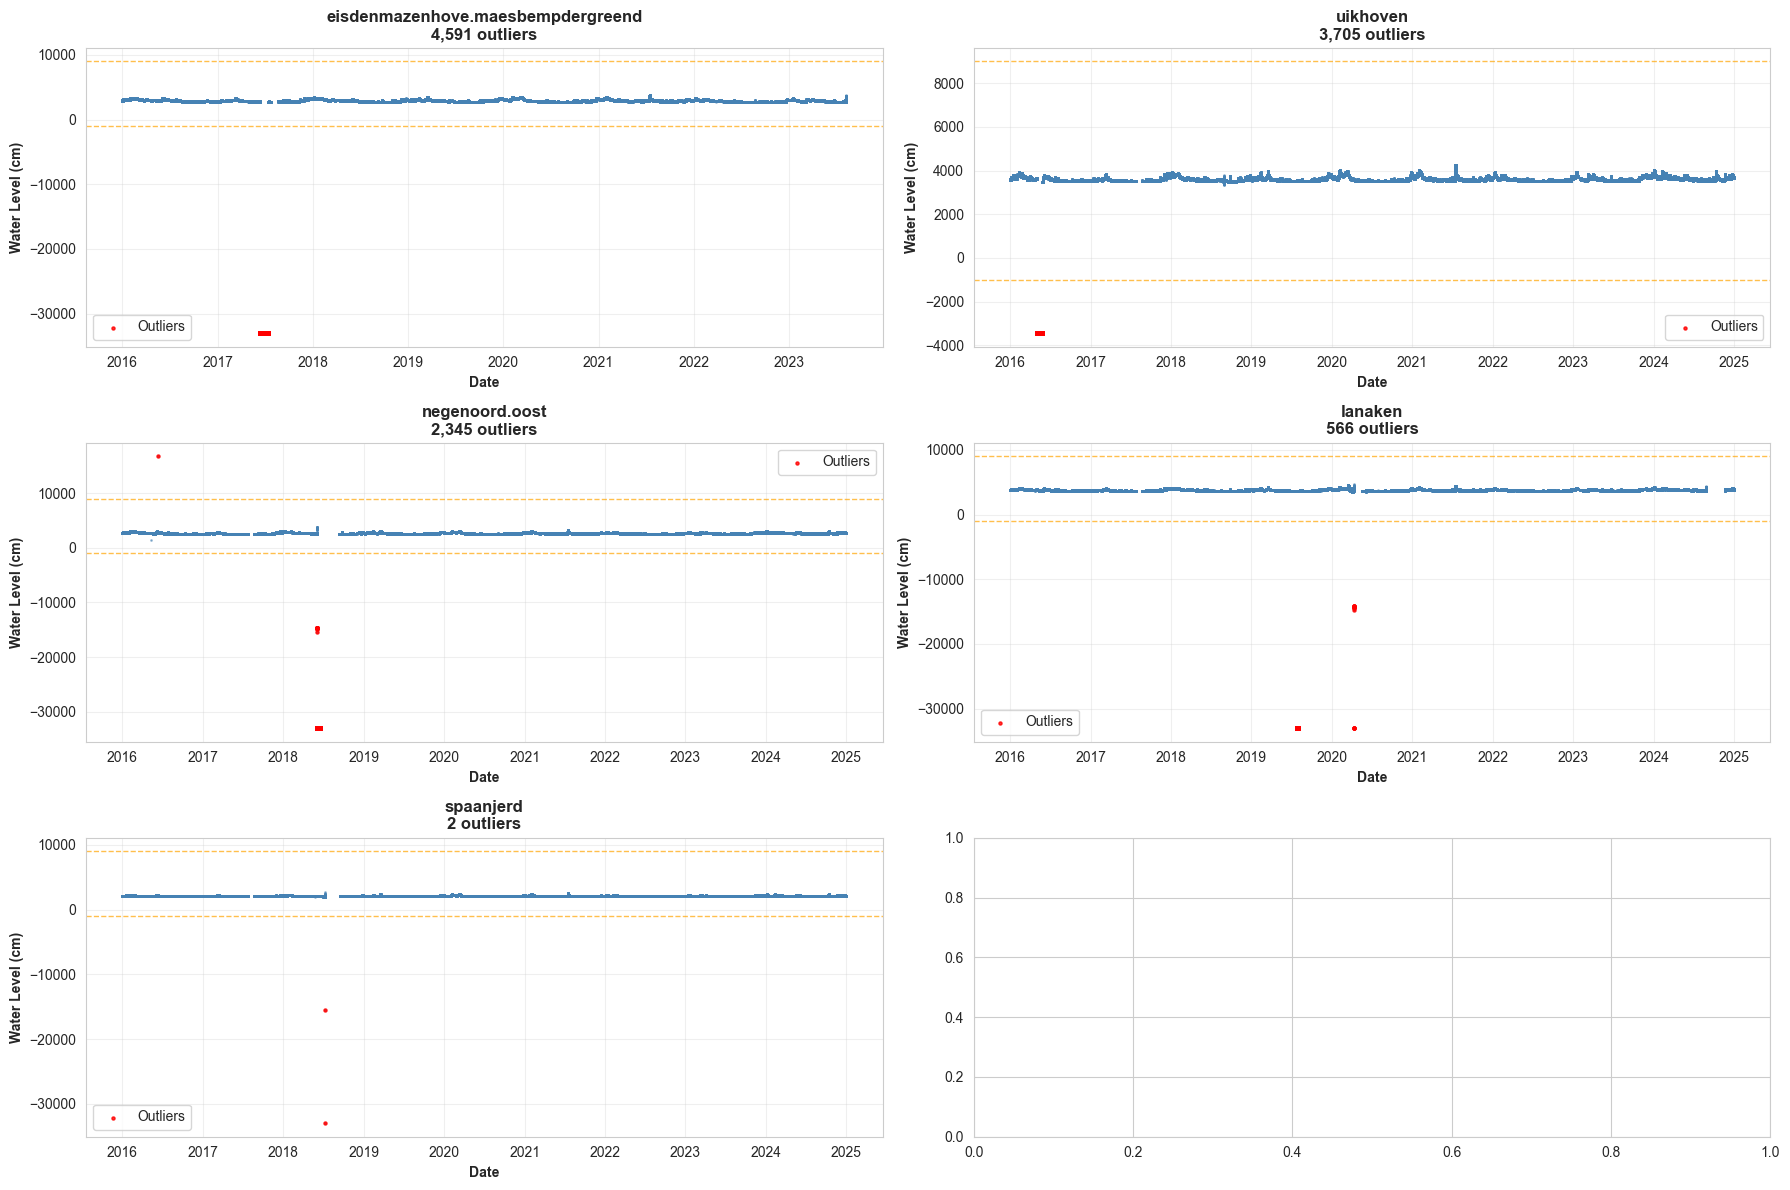

In [18]:
# Plot time series for stations with most outliers
print("Plotting time series for top 6 stations with outliers...\n")

top_outlier_stations = outliers_domain.groupby('station_code').size().sort_values(ascending=False).head(6).index

if len(top_outlier_stations) > 0:
    fig, axes = plt.subplots(3, 2, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, station in enumerate(top_outlier_stations):
        ax = axes[idx]
        station_df = combined_df[combined_df['station_code'] == station].sort_values('timestamp')
        
        # Plot all data
        ax.scatter(station_df['timestamp'], station_df['water_level_cm'], alpha=0.5, s=1, color='steelblue')
        
        # Highlight outliers
        outliers_station = outliers_domain[outliers_domain['station_code'] == station]
        ax.scatter(outliers_station['timestamp'], outliers_station['water_level_cm'], 
                  alpha=0.8, s=5, color='red', label='Outliers')
        
        # Add threshold lines
        ax.axhline(y=DOMAIN_MIN, color='orange', linestyle='--', linewidth=1, alpha=0.7)
        ax.axhline(y=DOMAIN_MAX, color='orange', linestyle='--', linewidth=1, alpha=0.7)
        
        ax.set_title(f"{station}\n{len(outliers_station):,} outliers", fontweight='bold')
        ax.set_xlabel('Date', fontweight='bold')
        ax.set_ylabel('Water Level (cm)', fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No problematic stations found!")

---
# Part 2: Define Cleaning Rules
---

## 8. Cleaning Rules Based on EDA Findings

In [42]:
print("="*80)
print("CLEANING RULES DEFINITION")
print("="*80)

print("""
Based on the EDA, we define the following cleaning rules:

🎯 Rule 1: Domain Knowledge Constraints
   • Minimum: -1000 cm (-10m below NAP)
   • Maximum: 8000 cm (+80m above NAP)
   • Rationale: Netherlands lowest point is ~-7m, extreme floods rarely exceed +10m
   • Buffer: 30m maximum is generous to avoid removing legitimate extreme events

🎯 Rule 2: Remove Duplicate Timestamps
   • Remove any duplicate timestamp entries within a station
   • Rationale: Measurement errors or API artifacts

🎯 Rule 3: Physical Impossibility Filter
   • Rate of change > 500 cm/hour (unrealistic)
   • Rationale: Water levels don't change that rapidly in rivers
   • Note: Applied cautiously to avoid removing flash flood events

💡 Conservative Approach:
   We use domain knowledge (Rule 1) as the primary filter.
   Statistical methods (IQR, percentiles) are too aggressive and might remove
   legitimate extreme events that are important for erosion modeling.

""")

# Define thresholds
CLEAN_MIN = -1000  # cm
CLEAN_MAX = 8000   # cm
MAX_RATE_CHANGE = 2000  # cm/hour

print(f"✅ Cleaning thresholds set:")
print(f"   Min value: {CLEAN_MIN} cm")
print(f"   Max value: {CLEAN_MAX} cm")
print(f"   Max rate of change: {MAX_RATE_CHANGE} cm/hour")

CLEANING RULES DEFINITION

Based on the EDA, we define the following cleaning rules:

🎯 Rule 1: Domain Knowledge Constraints
   • Minimum: -1000 cm (-10m below NAP)
   • Maximum: 8000 cm (+80m above NAP)
   • Rationale: Netherlands lowest point is ~-7m, extreme floods rarely exceed +10m
   • Buffer: 30m maximum is generous to avoid removing legitimate extreme events

🎯 Rule 2: Remove Duplicate Timestamps
   • Remove any duplicate timestamp entries within a station
   • Rationale: Measurement errors or API artifacts

🎯 Rule 3: Physical Impossibility Filter
   • Rate of change > 500 cm/hour (unrealistic)
   • Rationale: Water levels don't change that rapidly in rivers
   • Note: Applied cautiously to avoid removing flash flood events

💡 Conservative Approach:
   We use domain knowledge (Rule 1) as the primary filter.
   Statistical methods (IQR, percentiles) are too aggressive and might remove
   legitimate extreme events that are important for erosion modeling.


✅ Cleaning thresholds s

---
# Part 3: Apply Cleaning
---

## 9. Clean All Stations

In [43]:
def clean_station_data(df, station_code, min_val=-1000, max_val=8000, max_rate=4000):
    """
    Clean water level data for a single station.
    
    Args:
        df: DataFrame with water level data
        station_code: Station identifier
        min_val: Minimum acceptable value (cm)
        max_val: Maximum acceptable value (cm)
        max_rate: Maximum rate of change (cm/hour)
    
    Returns:
        cleaned_df: Cleaned DataFrame
        cleaning_stats: Dictionary with cleaning statistics
    """
    original_count = len(df)
    df_clean = df.copy()
    
    # Rule 1: Domain constraints
    domain_mask = (df_clean['water_level_cm'] >= min_val) & (df_clean['water_level_cm'] <= max_val)
    removed_domain = (~domain_mask).sum()
    df_clean = df_clean[domain_mask].copy()
    
    # Rule 2: Remove duplicates
    before_dup = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['timestamp'], keep='first')
    removed_duplicates = before_dup - len(df_clean)
    
    # Rule 3: Rate of change filter (optional, cautious)
    df_clean = df_clean.sort_values('timestamp').reset_index(drop=True)
    df_clean['time_diff_hours'] = df_clean['timestamp'].diff().dt.total_seconds() / 3600
    df_clean['value_diff'] = df_clean['water_level_cm'].diff().abs()
    df_clean['rate_of_change'] = df_clean['value_diff'] / df_clean['time_diff_hours']
    
    before_rate = len(df_clean)
    rate_mask = (df_clean['rate_of_change'].isna()) | (df_clean['rate_of_change'] <= max_rate)
    df_clean = df_clean[rate_mask].copy()
    removed_rate = before_rate - len(df_clean)
    
    # Remove temporary columns
    df_clean = df_clean.drop(columns=['time_diff_hours', 'value_diff', 'rate_of_change'])
    
    final_count = len(df_clean)
    total_removed = original_count - final_count
    
    cleaning_stats = {
        'station_code': station_code,
        'original_count': original_count,
        'final_count': final_count,
        'removed_total': total_removed,
        'removed_domain': removed_domain,
        'removed_duplicates': removed_duplicates,
        'removed_rate': removed_rate,
        'pct_removed': (total_removed / original_count * 100) if original_count > 0 else 0,
        'min_value': df_clean['water_level_cm'].min() if len(df_clean) > 0 else None,
        'max_value': df_clean['water_level_cm'].max() if len(df_clean) > 0 else None,
        'mean_value': df_clean['water_level_cm'].mean() if len(df_clean) > 0 else None
    }
    
    return df_clean, cleaning_stats

print("✅ Cleaning function defined!")

✅ Cleaning function defined!


In [44]:
print("="*80)
print("CLEANING ALL STATIONS")
print("="*80)

print(f"\n🧹 Processing {len(parquet_files)} stations...\n")

cleaning_results = []

for file in tqdm(parquet_files, desc="Cleaning stations"):
    # Load raw data
    df_raw = pd.read_parquet(file)
    station_code = df_raw['station_code'].iloc[0]
    
    # Clean
    df_clean, stats = clean_station_data(df_raw, station_code, CLEAN_MIN, CLEAN_MAX, MAX_RATE_CHANGE)
    
    # Save cleaned data
    if len(df_clean) > 0:
        output_path = OUTPUT_DIR / f"{station_code}.parquet"
        df_clean.to_parquet(output_path, index=False, compression='snappy')
        stats['status'] = 'success'
        stats['output_path'] = str(output_path)
    else:
        stats['status'] = 'failed_empty'
        stats['output_path'] = 'N/A'
    
    cleaning_results.append(stats)

cleaning_df = pd.DataFrame(cleaning_results)

print("\n✅ Cleaning complete!")

CLEANING ALL STATIONS

🧹 Processing 66 stations...



Cleaning stations: 100%|██████████| 66/66 [00:06<00:00, 10.52it/s]


✅ Cleaning complete!


---
# Part 4: Validation & Reporting
---

## 10. Cleaning Summary Statistics

In [45]:
print("="*80)
print("CLEANING SUMMARY")
print("="*80)

total_original = cleaning_df['original_count'].sum()
total_final = cleaning_df['final_count'].sum()
total_removed = cleaning_df['removed_total'].sum()

print(f"\n📊 Overall Statistics:\n")
print(f"   Original measurements: {total_original:,}")
print(f"   Final measurements: {total_final:,}")
print(f"   Removed: {total_removed:,} ({total_removed/total_original*100:.3f}%)\n")

print(f"📊 Breakdown by removal reason:\n")
print(f"   Domain constraints: {cleaning_df['removed_domain'].sum():,}")
print(f"   Duplicates: {cleaning_df['removed_duplicates'].sum():,}")
print(f"   Rate of change: {cleaning_df['removed_rate'].sum():,}\n")

print(f"📊 Stations by removal percentage:\n")
print(cleaning_df[['station_code', 'pct_removed']].sort_values('pct_removed', ascending=False).head(10).to_string(index=False))

print(f"\n✅ Status:\n")
print(cleaning_df['status'].value_counts())

CLEANING SUMMARY

📊 Overall Statistics:

   Original measurements: 27,828,328
   Final measurements: 27,817,105
   Removed: 11,223 (0.040%)

📊 Breakdown by removal reason:

   Domain constraints: 11,209
   Duplicates: 0
   Rate of change: 14

📊 Stations by removal percentage:

                     station_code  pct_removed
eisdenmazenhove.maesbempdergreend     1.177290
                         uikhoven     0.806252
                   negenoord.oost     0.520764
                          lanaken     0.133113
                        spaanjerd     0.000441
                    nijmegen.waal     0.000423
                             neer     0.000000
                             mook     0.000000
                   negenoord.west     0.000000
                      schoonhoven     0.000000

✅ Status:

status
success    66
Name: count, dtype: int64


## 11. Before/After Comparison

In [46]:
# Load cleaned data for comparison
print("Loading cleaned data for comparison...\n")

cleaned_files = sorted(list(OUTPUT_DIR.glob('*.parquet')))
all_cleaned_data = []

for file in tqdm(cleaned_files, desc="Loading cleaned data"):
    df = pd.read_parquet(file)
    all_cleaned_data.append(df)

cleaned_combined = pd.concat(all_cleaned_data, ignore_index=True)

print(f"✅ Loaded {len(cleaned_combined):,} cleaned measurements")

Loading cleaned data for comparison...



Loading cleaned data: 100%|██████████| 66/66 [00:00<00:00, 105.62it/s]


✅ Loaded 27,817,105 cleaned measurements


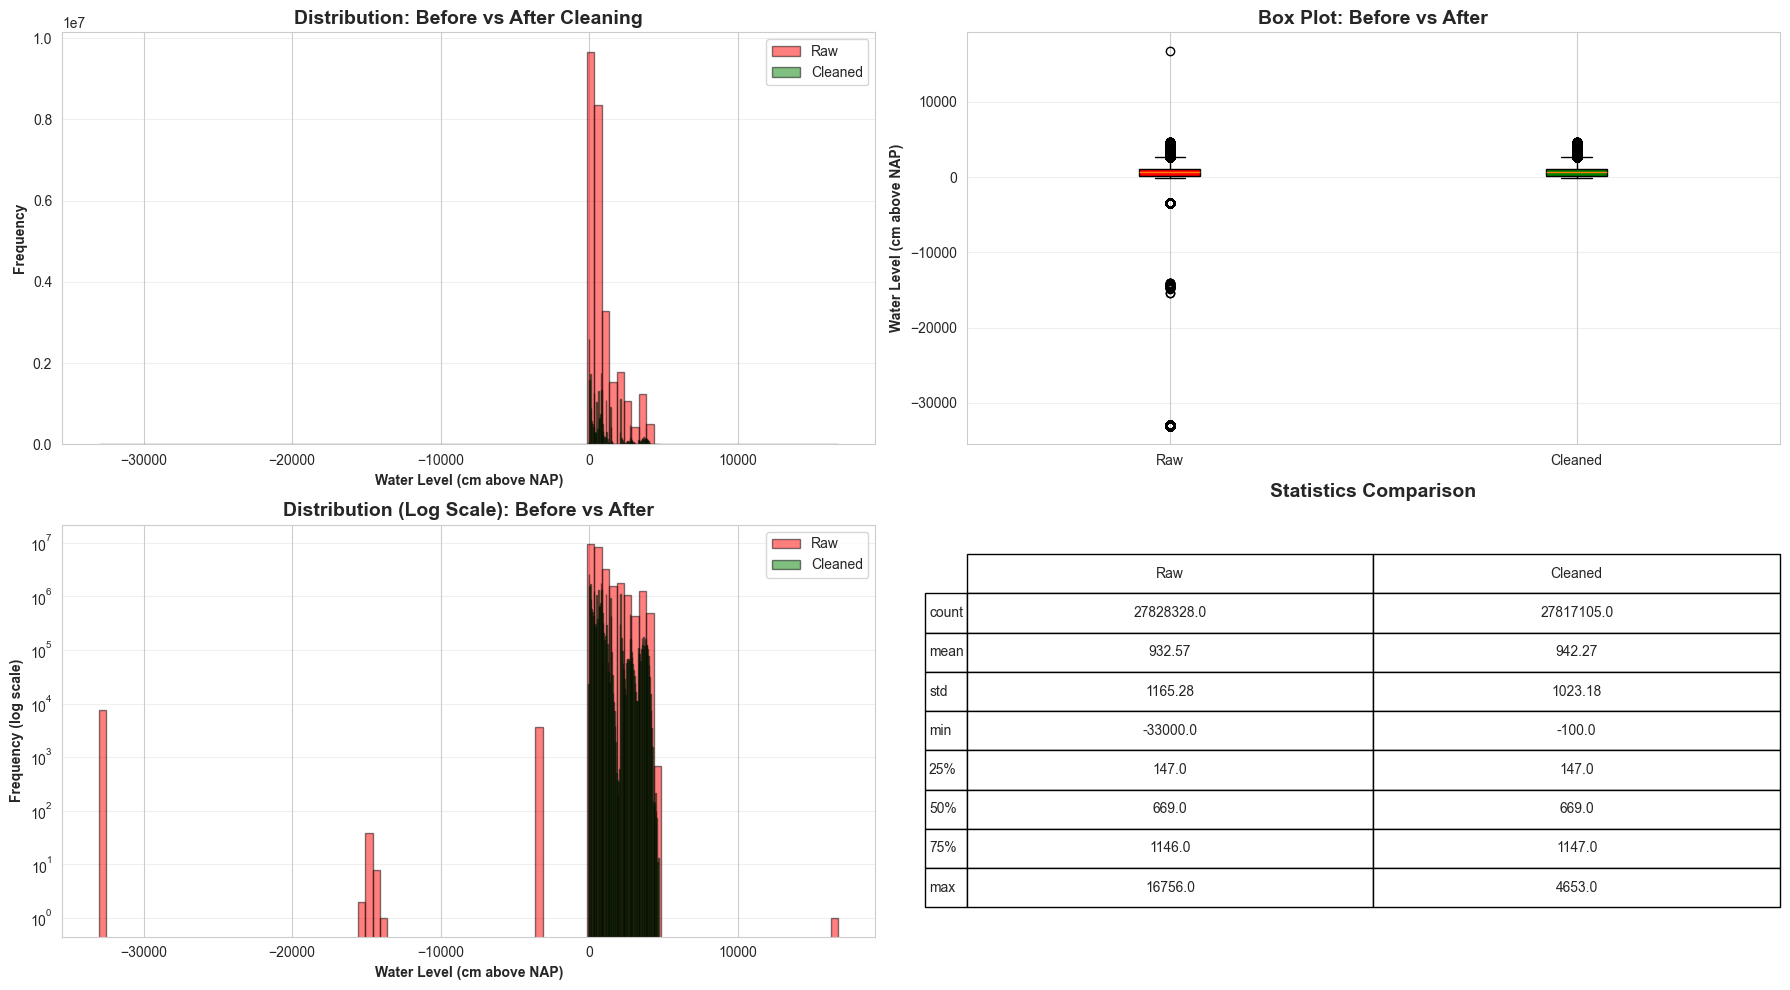

In [47]:
# Visualization: Before/After comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Histogram comparison
ax1 = axes[0, 0]
ax1.hist(combined_df['water_level_cm'], bins=100, alpha=0.5, label='Raw', color='red', edgecolor='black')
ax1.hist(cleaned_combined['water_level_cm'], bins=100, alpha=0.5, label='Cleaned', color='green', edgecolor='black')
ax1.set_xlabel('Water Level (cm above NAP)', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('Distribution: Before vs After Cleaning', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Box plot comparison
ax2 = axes[0, 1]
bp = ax2.boxplot([combined_df['water_level_cm'], cleaned_combined['water_level_cm']], 
                  labels=['Raw', 'Cleaned'], patch_artist=True)
bp['boxes'][0].set_facecolor('red')
bp['boxes'][1].set_facecolor('green')
ax2.set_ylabel('Water Level (cm above NAP)', fontweight='bold')
ax2.set_title('Box Plot: Before vs After', fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Extreme values focus
ax3 = axes[1, 0]
ax3.hist(combined_df['water_level_cm'], bins=100, alpha=0.5, label='Raw', color='red', edgecolor='black')
ax3.hist(cleaned_combined['water_level_cm'], bins=100, alpha=0.5, label='Cleaned', color='green', edgecolor='black')
ax3.set_yscale('log')
ax3.set_xlabel('Water Level (cm above NAP)', fontweight='bold')
ax3.set_ylabel('Frequency (log scale)', fontweight='bold')
ax3.set_title('Distribution (Log Scale): Before vs After', fontweight='bold', fontsize=14)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Statistics comparison
ax4 = axes[1, 1]
stats_comparison = pd.DataFrame({
    'Raw': combined_df['water_level_cm'].describe(),
    'Cleaned': cleaned_combined['water_level_cm'].describe()
})
ax4.axis('tight')
ax4.axis('off')
table = ax4.table(cellText=stats_comparison.values.round(2),
                  rowLabels=stats_comparison.index,
                  colLabels=stats_comparison.columns,
                  cellLoc='center',
                  loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax4.set_title('Statistics Comparison', fontweight='bold', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

In [53]:
print("=" * 80)
print("CLEANED TIME SERIES - ALL 66 STATIONS")
print("=" * 80)

print("\n📊 Plotting all CLEANED station time series...\n")

# Get cleaned files
cleaned_files = sorted(list(OUTPUT_DIR.glob('*.parquet')))

# Create grid
n_cols = 1
n_rows = len(cleaned_files)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4*n_rows))
axes = axes.flatten()

for idx, file in enumerate(tqdm(cleaned_files, desc="Plotting cleaned stations")):
    ax = axes[idx]
    
    # Load CLEANED station data
    df = pd.read_parquet(file)
    station_code = df['station_code'].iloc[0]
    
    # Sample for performance
    if len(df) > 10000:
        sample_idx = np.arange(0, len(df), 50)
        plot_df = df.iloc[sample_idx].sort_values('timestamp')
    else:
        plot_df = df.sort_values('timestamp')
    
    # Plot time series
    ax.plot(plot_df['timestamp'], plot_df['water_level_cm'], 
            linewidth=0.8, alpha=0.8, color='green')
    
    # Get data limits
    data_min = df['water_level_cm'].min()
    data_max = df['water_level_cm'].max()
    padding = (data_max - data_min) * 0.1
    
    ax.set_ylim(data_min - padding, data_max + padding)
    
    # Styling
    ax.set_title(f"{station_code} (CLEANED)", fontsize=10, fontweight='bold', color='green')
    ax.set_xlabel('Date', fontsize=7)
    ax.set_ylabel('Water Level (cm)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3, linewidth=0.3)
    
    # Stats
    stats_text = f"n={len(df):,}\nRange: {data_min:.0f} to {data_max:.0f} cm\nMean: {df['water_level_cm'].mean():.0f} cm"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            fontsize=7, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.savefig(OUTPUT_DIR.parent / 'all_stations_timeseries_CLEANED.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All CLEANED time series plotted!")
print(f"💾 Saved to: {OUTPUT_DIR.parent / 'all_stations_timeseries_CLEANED.png'}")
print(f"\n💡 All values should now be within [-1000, 8000] cm range")

CLEANED TIME SERIES - ALL 66 STATIONS

📊 Plotting all CLEANED station time series...



Plotting cleaned stations: 100%|██████████| 66/66 [00:03<00:00, 20.73it/s]



✅ All CLEANED time series plotted!
💾 Saved to: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaned/all_stations_timeseries_CLEANED.png

💡 All values should now be within [-1000, 8000] cm range


## 12. Generate Cleaning Report

In [48]:
print("="*80)
print("SAVING CLEANING REPORT")
print("="*80)

# Save detailed cleaning report
report_path = REPORT_DIR / "water_height_cleaning_report.csv"
cleaning_df.to_csv(report_path, index=False)
print(f"\n✅ Detailed report saved: {report_path}")

# Save summary statistics
summary_path = REPORT_DIR / "water_height_cleaning_summary.txt"
with open(summary_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("WATER HEIGHT CLEANING SUMMARY\n")
    f.write("="*80 + "\n\n")
    f.write(f"Date: {pd.Timestamp.now()}\n\n")
    f.write(f"Stations processed: {len(cleaning_df)}\n")
    f.write(f"Original measurements: {total_original:,}\n")
    f.write(f"Final measurements: {total_final:,}\n")
    f.write(f"Removed: {total_removed:,} ({total_removed/total_original*100:.3f}%)\n\n")
    f.write("Removal breakdown:\n")
    f.write(f"  - Domain constraints: {cleaning_df['removed_domain'].sum():,}\n")
    f.write(f"  - Duplicates: {cleaning_df['removed_duplicates'].sum():,}\n")
    f.write(f"  - Rate of change: {cleaning_df['removed_rate'].sum():,}\n\n")
    f.write("Cleaning rules applied:\n")
    f.write(f"  - Min value: {CLEAN_MIN} cm\n")
    f.write(f"  - Max value: {CLEAN_MAX} cm\n")
    f.write(f"  - Max rate: {MAX_RATE_CHANGE} cm/hour\n\n")
    f.write("Statistics (cleaned data):\n")
    f.write(cleaned_combined['water_level_cm'].describe().to_string())

print(f"✅ Summary saved: {summary_path}")

print(f"\n📂 Cleaned data location: {OUTPUT_DIR}")
print(f"📦 Files created: {len(list(OUTPUT_DIR.glob('*.parquet')))}")

SAVING CLEANING REPORT

✅ Detailed report saved: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaning_reports/water_height_cleaning_report.csv
✅ Summary saved: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaning_reports/water_height_cleaning_summary.txt

📂 Cleaned data location: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaned/water_height
📦 Files created: 66


## 13. Final Validation

In [49]:
print("="*80)
print("FINAL VALIDATION")
print("="*80)

print(f"\n✅ Quality checks:\n")

# Check 1: All values within domain
out_of_range = cleaned_combined[
    (cleaned_combined['water_level_cm'] < CLEAN_MIN) | 
    (cleaned_combined['water_level_cm'] > CLEAN_MAX)
]
print(f"1. Values within domain [{CLEAN_MIN}, {CLEAN_MAX}]:")
print(f"   {'✅ PASS' if len(out_of_range) == 0 else '❌ FAIL'} - {len(out_of_range)} out-of-range values\n")

# Check 2: No duplicate timestamps per station
duplicates = cleaned_combined.groupby('station_code')['timestamp'].apply(lambda x: x.duplicated().sum()).sum()
print(f"2. No duplicate timestamps:")
print(f"   {'✅ PASS' if duplicates == 0 else '❌ FAIL'} - {duplicates} duplicates found\n")

# Check 3: Data completeness
retention_rate = (total_final / total_original) * 100
print(f"3. Data retention rate:")
print(f"   {retention_rate:.2f}% of data retained")
print(f"   {'✅ PASS' if retention_rate > 95 else '⚠️  WARNING' if retention_rate > 90 else '❌ FAIL'}\n")

# Check 4: All stations present
missing_stations = set(combined_df['station_code'].unique()) - set(cleaned_combined['station_code'].unique())
print(f"4. All stations retained:")
print(f"   {'✅ PASS' if len(missing_stations) == 0 else '⚠️  WARNING'} - {len(missing_stations)} stations lost\n")

if len(missing_stations) > 0:
    print(f"   Missing: {missing_stations}\n")

print("="*80)
print("✅ CLEANING COMPLETE!")
print("="*80)
print(f"\n📂 Output: {OUTPUT_DIR}")
print(f"📊 Reports: {REPORT_DIR}")
print(f"🚀 Ready for feature engineering!\n")

FINAL VALIDATION

✅ Quality checks:

1. Values within domain [-1000, 8000]:
   ✅ PASS - 0 out-of-range values

2. No duplicate timestamps:
   ✅ PASS - 0 duplicates found

3. Data retention rate:
   99.96% of data retained
   ✅ PASS

4. All stations retained:
   ✅ PASS - 0 stations lost

✅ CLEANING COMPLETE!

📂 Output: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaned/water_height
📊 Reports: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaning_reports
🚀 Ready for feature engineering!

